In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1️⃣ Leer los 3 archivos
file_paths = {
    "EICH101": r"C:\Users\jupap\OneDrive - Universidad de los andes\Tesis Camiii\ProyectoGradoGEB\datos\EICH101.xlsx",
    "EICH102": r"C:\Users\jupap\OneDrive - Universidad de los andes\Tesis Camiii\ProyectoGradoGEB\datos\EICH102.xlsx",
    "EICH104": r"C:\Users\jupap\OneDrive - Universidad de los andes\Tesis Camiii\ProyectoGradoGEB\datos\EICH104.xlsx"
}

# Cargar los archivos en dataframes
e1 = pd.read_excel(file_paths["EICH101"])
e2 = pd.read_excel(file_paths["EICH102"])
e3 = pd.read_excel(file_paths["EICH104"])

# 2️⃣ Filtrar registros según ORIG_RAW_VOLUME
e1 = e1[e1["ORIG_RAW_VOLUME"] <= 60]
e2 = e2[e2["ORIG_RAW_VOLUME"] <= 120]
e3 = e3[e3["ORIG_RAW_VOLUME"] <= 350]

# 3️⃣ Convertir EFFECTIVE_DATE a formato de fecha
e1["EFFECTIVE_DATE"] = pd.to_datetime(e1["EFFECTIVE_DATE"], errors='coerce')
e2["EFFECTIVE_DATE"] = pd.to_datetime(e2["EFFECTIVE_DATE"], errors='coerce')
e3["EFFECTIVE_DATE"] = pd.to_datetime(e3["EFFECTIVE_DATE"], errors='coerce')

# Agregar columna de empresa e identificarla con One-Hot Encoding
e1["empresa"] = "EICH101"
e2["empresa"] = "EICH102"
e3["empresa"] = "EICH104"

# Unificar los tres DataFrames en uno solo
df = pd.concat([e1, e2, e3], ignore_index=True)

# Aplicar One-Hot Encoding a la columna "empresa"
df = pd.get_dummies(df, columns=["empresa"])

# 4️⃣ Eliminar registros con valores nulos, duplicados y negativos
df = df.dropna()  # Eliminar registros con valores nulos
df = df.drop_duplicates()  # Eliminar duplicados
# Seleccionar solo columnas numéricas antes de eliminar valores negativos
numeric_columns = df.select_dtypes(include=["number"]).columns
df = df[df[numeric_columns].ge(0).all(axis=1)]

# 5️⃣ Aplicar normalización a ORIG_RAW_VOLUME usando percentil 99
global_max = np.percentile(df["ORIG_RAW_VOLUME"], 99)
df["ORIG_RAW_VOLUME_NORM"] = df["ORIG_RAW_VOLUME"] / global_max
df["ORIG_RAW_VOLUME_NORM"] = np.clip(df["ORIG_RAW_VOLUME_NORM"], 0, 1)  # Asegurar que esté entre 0 y 1


In [4]:
print(df.head())

   ORIG_STD_VOLUME  STD_VOLUME  ORIG_TEMPERATURE  TEMPERATURE   PRESSURE  \
0         0.000000    0.000000         23.304819    23.304819  17.686537   
1        17.516075   17.516081         23.449533    23.449533  17.705580   
2        19.025777   19.025784         23.625006    23.625006  17.690292   
3        14.820577   14.820582         23.636658    23.636658  17.708681   
4        14.184913   14.184918         23.636869    23.636869  17.692707   

   ORIG_PRESSURE  ORIG_RAW_VOLUME  RAW_VOLUME      EFFECTIVE_DATE  \
0      17.686537            0.000       0.000 2018-09-03 09:00:00   
1      17.705580           25.875      25.875 2018-09-03 10:00:00   
2      17.690292           28.125      28.125 2018-09-03 11:00:00   
3      17.708681           21.875      21.875 2018-09-03 12:00:00   
4      17.692707           21.000      21.000 2018-09-03 13:00:00   

   empresa_EICH101  empresa_EICH102  empresa_EICH104  ORIG_RAW_VOLUME_NORM  
0             True            False            Fals

In [ ]:
import os
import pandas as pd
import numpy as np
import pywt
import matplotlib.pyplot as plt
import math

# Crear la carpeta donde se guardarán las imágenes
output_folder = "C:/Users/diana/OneDrive - Universidad de los Andes/Documentos/9no Semestre/TesisGEB_AlejaYCami/Repositorio/ProyectoGradoGEB/modelos/escalogramas"
os.makedirs(output_folder, exist_ok=True)

# Escalas para la Transformada Wavelet Continua (CWT)
scales = np.arange(1, 128)

# Lista de empresas (columnas One-Hot Encoding)
empresas = ['empresa_EICH101', 'empresa_EICH102', 'empresa_EICH104']

# Recorrer el archivo secuencialmente
df_sorted = df.sort_values(by="EFFECTIVE_DATE")

for empresa in empresas:
    # Filtrar solo las filas donde la empresa tiene valor 1 en One-Hot Encoding
    df_empresa = df_sorted[df_sorted[empresa] == 1]

    # Obtener los años únicos en el DataFrame
    years = df_empresa['EFFECTIVE_DATE'].dt.year.unique()

    for year in years:
        df_year = df_empresa[df_empresa['EFFECTIVE_DATE'].dt.year == year]

        # Obtener las semanas únicas ordenadas
        weeks = sorted(df_year['EFFECTIVE_DATE'].dt.isocalendar().week.unique())

        for week in weeks:
            df_week = df_year[df_year['EFFECTIVE_DATE'].dt.isocalendar().week == week]

            if not df_week.empty:
                # Extraer la señal de la semana (manteniendo valores originales sin escalar)
                signal_week = df_week['ORIG_RAW_VOLUME_NORM'].values

                # Aplicar la Transformada Wavelet Continua (CWT) con Morlet
                coefficients, frequencies = pywt.cwt(signal_week, scales, 'morl')

                # Crear la figura del escalograma
                plt.figure(figsize=(10, 6))
                plt.imshow(np.abs(coefficients), aspect="auto", cmap="jet",
                           extent=[0, len(signal_week), scales[-1], scales[0]])
                plt.colorbar(label="Magnitud")
                plt.title(f"Escalograma - {empresa} - Año {year} - Semana {week}", fontsize=12, fontweight="bold")
                plt.xlabel("Horas de la Semana")
                plt.ylabel("Escala")

                # Guardar la imagen
                filename = f"{empresa}_Año{year}_Semana{week}.png".replace(" ", "_")
                filepath = os.path.join(output_folder, filename)
                plt.savefig(filepath, dpi=300, bbox_inches="tight")
                plt.close()

# Listar los archivos generados
generated_files = os.listdir(output_folder)
print("Ejemplo de archivos generados:", generated_files[:10])  # Mostrar solo los primeros 10 archivos como muestra

Ejemplo de archivos generados: ['empresa_EICH101_Año2018_Semana1.png', 'empresa_EICH101_Año2018_Semana36.png', 'empresa_EICH101_Año2018_Semana37.png', 'empresa_EICH101_Año2018_Semana38.png', 'empresa_EICH101_Año2018_Semana39.png', 'empresa_EICH101_Año2018_Semana40.png', 'empresa_EICH101_Año2018_Semana41.png', 'empresa_EICH101_Año2018_Semana42.png', 'empresa_EICH101_Año2018_Semana43.png', 'empresa_EICH101_Año2018_Semana44.png']


## CNN

#### Carga Imagenes Image Generator

In [2]:
import tensorflow as tf 
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Definir las rutas del dataset
dataset_path = "C:/Users/diana/OneDrive - Universidad de los Andes/Documentos/9no Semestre/TesisGEB_AlejaYCami/Repositorio/ProyectoGradoGEB/modelos"  # 📌 Reemplaza con la ruta real

# Generador de datos con aumentación para entrenar mejor
datagen = ImageDataGenerator(
    rescale=1./255,  # Normalizar los valores de los píxeles a [0,1]
    validation_split=0.2  # Usar 20% de las imágenes para validación
)

# Cargar las imágenes en lotes
batch_size = 32
img_size = (128, 128)  # Ajusta según la resolución de tus escalogramas

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",  # Clasificación binaria (normal vs anómalo)
    subset="training"
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="validation"
)


Found 669 images belonging to 2 classes.
Found 167 images belonging to 2 classes.


In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# 🔹 Definir la arquitectura de la CNN
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),  # Reduce overfitting
    Dense(1, activation='sigmoid')  # Salida binaria (normal vs anómalo)
])

# 🔹 Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 🔹 Mostrar resumen del modelo
model.summary()

# Definir las rutas del dataset
dataset_path = "C:/Users/diana/OneDrive - Universidad de los Andes/Documentos/9no Semestre/TesisGEB_AlejaYCami/Repositorio/ProyectoGradoGEB/modelos"  # 📌 Reemplaza con la ruta real

# Generador de datos con aumentación para entrenar mejor
datagen = ImageDataGenerator(
    rescale=1./255,  # Normalizar los valores de los píxeles a [0,1]
    validation_split=0.2  # Usar 20% de las imágenes para validación
)

# Cargar las imágenes en lotes
batch_size = 32
img_size = (128, 128)  # Ajusta según la resolución de tus escalogramas

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",  # Clasificación binaria (normal vs anómalo)
    subset="training"
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="validation"
)

# 🔹 Calcular pesos de clases para balancear datos
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}

# 🔹 Entrenar el modelo con class_weight
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    class_weight=class_weight_dict,
    verbose=1
)

# 🔹 Guardar el modelo después del entrenamiento
model.save("modelo_cnn_escalogramas.h5")


c:\Users\diana\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Found 669 images belonging to 2 classes.
Found 167 images belonging to 2 classes.


c:\Users\diana\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.6262 - loss: 0.6686 - val_accuracy: 0.8323 - val_loss: 0.4554
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.8542 - loss: 0.3919 - val_accuracy: 0.8263 - val_loss: 0.3910
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.9169 - loss: 0.2169 - val_accuracy: 0.8323 - val_loss: 0.3531
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.9167 - loss: 0.2502 - val_accuracy: 0.8383 - val_loss: 0.3298
Epoch 5/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.9031 - loss: 0.2305 - val_accuracy: 0.8503 - val_loss: 0.3040
Epoch 6/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.9165 - loss: 0.2184 - val_accuracy: 0.8263 - val_loss: 0.3393
Epoch 7/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.9309 - loss: 0.1827 - val_accuracy: 0.8204 - val_loss: 0.4783
Epoch 8/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9339 - loss: 0.1825 - val_accuracy: 0.8563 - val_loss:

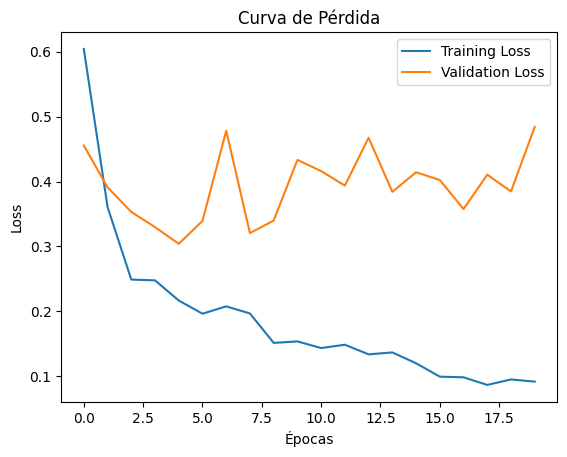

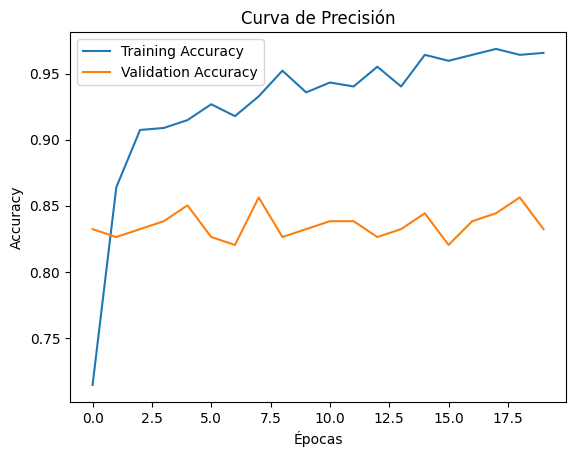

In [6]:
import matplotlib.pyplot as plt

# Graficar Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.title('Curva de Pérdida')
plt.show()

# Graficar Accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Curva de Precisión')
plt.show()


In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# 🔹 Definir la arquitectura de la CNN con Dropout
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2,2),
    Dropout(0.2),  # 🔹 Agregar Dropout después de la primera capa convolucional

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.3),  # 🔹 Agregar Dropout después de la segunda capa convolucional

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Dropout(0.4),  # 🔹 Agregar Dropout después de la tercera capa convolucional

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),  # 🔹 Agregar Dropout antes de la salida
    Dense(1, activation='sigmoid')  # Salida binaria (normal vs anómalo)
])

# 🔹 Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 🔹 Mostrar resumen del modelo
model.summary()

# Definir las rutas del dataset
dataset_path = "C:/Users/diana/OneDrive - Universidad de los Andes/Documentos/9no Semestre/TesisGEB_AlejaYCami/Repositorio/ProyectoGradoGEB/modelos"  # 📌 Reemplaza con la ruta real

# Generador de datos con aumentación para entrenar mejor
datagen = ImageDataGenerator(
    rescale=1./255,  # Normalizar los valores de los píxeles a [0,1]
    validation_split=0.2  # Usar 20% de las imágenes para validación
)

# Cargar las imágenes en lotes
batch_size = 32
img_size = (128, 128)  # Ajusta según la resolución de tus escalogramas

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",  # Clasificación binaria (normal vs anómalo)
    subset="training"
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="validation"
)

# 🔹 Calcular pesos de clases para balancear datos
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}

# 🔹 Entrenar el modelo con class_weight y Dropout
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    class_weight=class_weight_dict,
    verbose=1
)

# 🔹 Guardar el modelo después del entrenamiento
model.save("modelo_cnn_dropout.h5")


c:\Users\diana\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Found 669 images belonging to 2 classes.
Found 167 images belonging to 2 classes.


c:\Users\diana\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.5691 - loss: 0.8165 - val_accuracy: 0.8084 - val_loss: 0.4776
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.7802 - loss: 0.4893 - val_accuracy: 0.8204 - val_loss: 0.4258
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.8225 - loss: 0.4148 - val_accuracy: 0.8204 - val_loss: 0.4061
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.8641 - loss: 0.3313 - val_accuracy: 0.8204 - val_loss: 0.4006
Epoch 5/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.8963 - loss: 0.2838 - val_accuracy: 0.8263 - val_loss: 0.3714
Epoch 6/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.9306 - loss: 0.2062 - val_accuracy: 0.8323 - val_loss: 0.3349
Epoch 7/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.9215 - loss: 0.1909 - val_accuracy: 0.7784 - val_loss: 0.3856
Epoch 8/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9250 - loss: 0.2179 - val_accuracy: 0.8263 - val_loss:

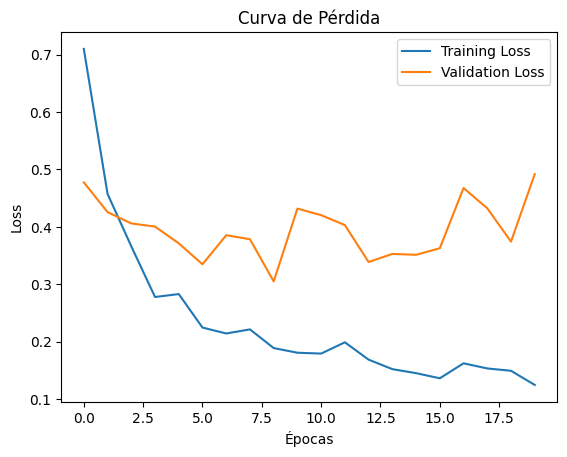

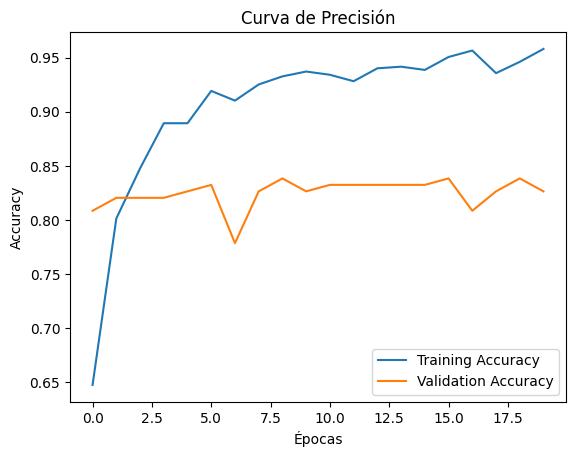

In [8]:
import matplotlib.pyplot as plt

# Graficar Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.title('Curva de Pérdida')
plt.show()

# Graficar Accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Curva de Precisión')
plt.show()


In [1]:
# -*- coding: utf-8 -*-
"""
Created on Mon Feb 24 20:03:03 2025
"""

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

# Parámetros
img_size = (224, 224)  # Tamaño de imagen compatible con MobileNetV2
batch_size = 32
epochs = 10
data_dir = r"C:/Users/diana/OneDrive - Universidad de los Andes/Documentos/9no Semestre/TesisGEB_AlejaYCami/Repositorio/ProyectoGradoGEB/modelos"  # 📌 Reemplaza con la ruta real
  # Carpeta principal

# Generador de datos con división en entrenamiento (80%) y validación (20%)
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Generadores para entrenamiento y validación
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="training"
)

test_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="validation"
)

# Cargar MobileNetV2 sin la capa de clasificación final
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet")

# Congelar capas preentrenadas para que no se modifiquen
base_model.trainable = False

# Agregar nuevas capas de clasificación
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
outputs = Dense(1, activation="sigmoid")(x)  # Clasificación binaria

# Crear el modelo final
model = Model(inputs=base_model.input, outputs=outputs)

# Compilar el modelo
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# Entrenar el modelo
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=epochs
)

# Evaluar el modelo
test_loss, test_acc = model.evaluate(test_generator)
print(f"Precisión en el conjunto de prueba: {test_acc * 100:.2f}%")

# Guardar el modelo entrenado
model.save("modelo_anomalias_MobileNetV2.h5")


Found 669 images belonging to 2 classes.
Found 167 images belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


c:\Users\diana\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 70s 3s/step - accuracy: 0.6741 - loss: 0.5980 - val_accuracy: 0.8204 - val_loss: 0.4498
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.9068 - loss: 0.2007 - val_accuracy: 0.8204 - val_loss: 0.5299
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.9256 - loss: 0.2046 - val_accuracy: 0.8383 - val_loss: 0.4336
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.9294 - loss: 0.1820 - val_accuracy: 0.8144 - val_loss: 0.6044
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.9400 - loss: 0.1546 - val_accuracy: 0.8024 - val_loss: 0.3941
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.9433 - loss: 0.1562 - val_accuracy: 0.8383 - val_loss: 0.4215
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.9468 - loss: 0.1343 - val_accuracy: 0.8144 - val_loss: 0.3889
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.9449 - loss: 0.1492 - val_accuracy: 0.8263 - val_loss:

Precisión en el conjunto de prueba: 85.03%


In [ ]:
# -*- coding: utf-8 -*-
"""
Created on Mon Feb 24 19:01:31 2025
"""

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, ResNet50, VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Flatten

# Parámetros
img_size = (224, 224)  # Tamaño de imagen compatible con los modelos
batch_size = 32
epochs = 10
data_dir = r"C:/Users/diana/OneDrive - Universidad de los Andes/Documentos/9no Semestre/TesisGEB_AlejaYCami/Repositorio/ProyectoGradoGEB/modelos"  # 📌 Reemplaza con la ruta real

# Generador de datos con división en entrenamiento (80%) y validación (20%)
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Generadores para entrenamiento y validación
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="training"
)

test_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="validation"
)

# Función corregida para construir modelos
def build_model(base_model):
    base_model.trainable = False  # Congelar capas preentrenadas
    
    # Asegurar que la entrada y salida están correctamente encadenadas
    inputs = base_model.input  # Obtener la entrada original del modelo base
    x = base_model.output  # Obtener la salida del modelo base
    
    # Aplicar GlobalAveragePooling2D para reducir dimensiones
    x = GlobalAveragePooling2D()(x) if "mobilenet" in base_model.name.lower() or "resnet" in base_model.name.lower() else Flatten()(x)
    
    # Agregar capas densas
    x = Dense(128, activation="relu")(x)
    outputs = Dense(1, activation="sigmoid")(x)  # Capa de salida para clasificación binaria
    
    # Crear el modelo final correctamente encadenado
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Definir los tres modelos
models = {
    "MobileNetV2": MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet"),
    "ResNet34": ResNet50(input_shape=(224, 224, 3), include_top=False, weights="imagenet"),  # ResNet50 se aproxima a ResNet34 en TF
    "VGG16bn": VGG16(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
}

# Entrenar y evaluar cada modelo
for name, base_model in models.items():
    print(f"\nEntrenando modelo: {name}")
    
    model = build_model(base_model)  # Crear el modelo

    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    
    history = model.fit(
        train_generator,
        validation_data=test_generator,
        epochs=epochs
    )

    test_loss, test_acc = model.evaluate(test_generator)
    print(f"Precisión de {name} en el conjunto de prueba: {test_acc * 100:.2f}%")

    # Guardar el modelo
    model.save(f"modelo_anomalias_{name}.h5")


Found 669 images belonging to 2 classes.
Found 167 images belonging to 2 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step

Entrenando modelo: MobileNetV2
Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.6175 - loss: 0.6324 - val_accuracy: 0.8144 - val_loss: 0.4140
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.8999 - loss: 0.2283 - val_accuracy: 0.7784 - val_loss: 0.4293
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.9236 - loss: 0.1954 - val_accuracy: 0.8144 - val_loss: 0.5316
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.9138 - loss: 0.2427 - val_accuracy: 0.8144 - val_loss: 0.4143
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.9137 - loss: 0.2143 - val_accuracy: 0.8204 - val_loss: 0.4632
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.9300 - loss: 0.1736 - val_accuracy: 0.8323 - val_loss: 0.4246
Epoch 7/10
21/21 ━━━━━━━━━━

Precisión de MobileNetV2 en el conjunto de prueba: 83.83%

Entrenando modelo: ResNet34
Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.5805 - loss: 0.6897 - val_accuracy: 0.5749 - val_loss: 0.6329
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 75s 4s/step - accuracy: 0.5891 - loss: 0.6478 - val_accuracy: 0.7066 - val_loss: 0.5723
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 64s 3s/step - accuracy: 0.7423 - loss: 0.5969 - val_accuracy: 0.6467 - val_loss: 0.5885
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 60s 3s/step - accuracy: 0.7174 - loss: 0.5798 - val_accuracy: 0.8204 - val_loss: 0.4957
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 74s 4s/step - accuracy: 0.7279 - loss: 0.5593 - val_accuracy: 0.7066 - val_loss: 0.5706
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 82s 4s/step - accuracy: 0.6770 - loss: 0.5574 - val_accuracy: 0.7784 - val_loss: 0.4851
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 75s 4s/step - accuracy: 0.7533 - loss: 0.5032 - val_accuracy: 0.8204 - val_loss: 0.4522
Epoch 8/10
21/21 ━━━━━━━━━━━━━━

Precisión de ResNet34 en el conjunto de prueba: 83.83%

Entrenando modelo: VGG16bn
Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 153s 7s/step - accuracy: 0.5568 - loss: 1.9486 - val_accuracy: 0.7904 - val_loss: 0.4497
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 99s 5s/step - accuracy: 0.8763 - loss: 0.3199 - val_accuracy: 0.8323 - val_loss: 0.4096
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 112s 5s/step - accuracy: 0.9155 - loss: 0.2285 - val_accuracy: 0.8323 - val_loss: 0.4231
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 113s 5s/step - accuracy: 0.9430 - loss: 0.1901 - val_accuracy: 0.8263 - val_loss: 0.4392
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 116s 6s/step - accuracy: 0.9443 - loss: 0.1739 - val_accuracy: 0.8204 - val_loss: 0.4534
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 114s 5s/step - accuracy: 0.9515 - loss: 0.1597 - val_accuracy: 0.8383 - val_loss: 0.4059
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 109s 5s/step - accuracy: 0.9558 - loss: 0.1621 - val_accuracy: 0.8383 - val_loss: 0.4192
Epoch 8/10
21/21 ━━━━━━━━━━━━

Precisión de VGG16bn en el conjunto de prueba: 83.83%


In [10]:
from tensorflow.keras.models import load_model

# Cargar el modelo guardado
modeloMNV2 = load_model("modelo_anomalias_MobileNetV2.h5")
modeloRN34 = load_model("modelo_anomalias_ResNet34.h5")
modeloVGG16 = load_model("modelo_anomalias_VGG16bn.h5")               


In [ ]:
# -*- coding: utf-8 -*-
"""
Created on Mon Feb 24 19:01:31 2025
"""

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, ResNet50, VGG16
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Flatten
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, f1_score, precision_score
import seaborn as sns
import matplotlib.pyplot as plt

# Parámetros
img_size = (224, 224)  
batch_size = 32
epochs = 10
data_dir = r"C:/Users/diana/OneDrive - Universidad de los Andes/Documentos/9no Semestre/TesisGEB_AlejaYCami/Repositorio/ProyectoGradoGEB/modelos"  # 📌 Reemplaza con la ruta real

# Generador de datos con división en entrenamiento (80%) y validación (20%)
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Generadores para entrenamiento y validación
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="training"
)

test_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="validation",
    shuffle=False  # ⚠ Importante: Evitar barajar los datos para mantener correspondencia en y_pred
)

# Función para construir modelos
def build_model(base_model):
    base_model.trainable = False  # Congelar capas preentrenadas
    
    inputs = base_model.input
    x = base_model.output
    x = GlobalAveragePooling2D()(x) if "mobilenet" in base_model.name.lower() or "resnet" in base_model.name.lower() else Flatten()(x)
    
    x = Dense(128, activation="relu")(x)
    outputs = Dense(1, activation="sigmoid")(x)  
    
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Definir los modelos
models = {
    "MobileNetV2": MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet"),
    "ResNet34": ResNet50(input_shape=(224, 224, 3), include_top=False, weights="imagenet"),  
    "VGG16bn": VGG16(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
}

# Entrenar y evaluar cada modelo
for name, base_model in models.items():
    print(f"\nEntrenando modelo: {name}")
    
    model = build_model(base_model)  

    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    
    history = model.fit(
        train_generator,
        validation_data=test_generator,
        epochs=epochs
    )

    test_loss, test_acc = model.evaluate(test_generator)
    print(f"Precisión de {name} en el conjunto de prueba: {test_acc * 100:.2f}%")

    # Guardar el modelo
    model.save(f"modelo_anomalias_{name}.h5")  

    # 🚀 Guardar datos de validación en NumPy
    print(f"\nGuardando datos de validación para {name}...\n")
    
    X_val = np.concatenate([test_generator[i][0] for i in range(len(test_generator))])
    y_val = np.concatenate([test_generator[i][1] for i in range(len(test_generator))])

    np.save(f"X_val_{name}.npy", X_val)
    np.save(f"y_val_{name}.npy", y_val)

    print(f"✅ Datos de validación guardados en X_val_{name}.npy y y_val_{name}.npy")

    # 🚀 Calcular métricas adicionales después del entrenamiento
    print(f"\nEvaluando métricas para {name}...\n")

    # Obtener etiquetas reales de validación
    y_val_classes = test_generator.classes  

    # Obtener predicciones del modelo
    y_pred_proba = model.predict(test_generator)  
    y_pred = (y_pred_proba > 0.5).astype(int).flatten()  

    # Matriz de Confusión
    matriz_conf = confusion_matrix(y_val_classes, y_pred)
    print("Matriz de Confusión:\n", matriz_conf)

    # Reporte de clasificación
    print("Reporte de Clasificación:\n", classification_report(y_val_classes, y_pred))

    # Obtener métricas individuales
    f1 = f1_score(y_val_classes, y_pred, average='weighted')
    precision = precision_score(y_val_classes, y_pred, average='weighted')

    print(f"F1-Score: {f1}")
    print(f"Precisión: {precision}")

    # Extraer valores de la matriz de confusión
    TN, FP, FN, TP = matriz_conf.ravel()

    # Error Tipo I (Falsos Positivos)
    error_tipo_1 = FP

    # Error Tipo II (Falsos Negativos)
    error_tipo_2 = FN

    print(f"Error Tipo I (Falsos Positivos): {error_tipo_1}")
    print(f"Error Tipo II (Falsos Negativos): {error_tipo_2}")

    # 📊 Visualizar la Matriz de Confusión
    plt.figure(figsize=(6, 5))
    sns.heatmap(matriz_conf, annot=True, fmt="d", cmap="Blues", xticklabels=["Clase 0", "Clase 1"], yticklabels=["Clase 0", "Clase 1"])
    plt.xlabel("Predicho")
    plt.ylabel("Real")
    plt.title(f"Matriz de Confusión - {name}")
    plt.show()


Found 586 images belonging to 2 classes.
Found 561 images belonging to 2 classes.
Found 275 images belonging to 2 classes.
Total imágenes en entrenamiento: 586
Total imágenes en validación: 561
Total imágenes en prueba: 275

Entrenando modelo: MobileNetV2
Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 75s 4s/step - accuracy: 0.7266 - loss: 0.4811 - val_accuracy: 0.9216 - val_loss: 0.2059
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 60s 3s/step - accuracy: 0.9127 - loss: 0.2388 - val_accuracy: 0.9109 - val_loss: 0.2044
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 61s 3s/step - accuracy: 0.8951 - loss: 0.2374 - val_accuracy: 0.9412 - val_loss: 0.1796
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/step - accuracy: 0.9342 - loss: 0.1857 - val_accuracy: 0.9430 - val_loss: 0.1506
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 57s 3s/step - accuracy: 0.9264 - loss: 0.1886 - val_accuracy: 0.9394 - val_loss: 0.1732
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 56s 3s/step - accuracy: 0.9414 - loss: 0.1449 - val_accuracy: 0.9519 - val_l

Precisión de MobileNetV2 en el conjunto de prueba: 86.91%

Guardando datos de validación y prueba para MobileNetV2...

✅ Datos guardados en X_val_MobileNetV2.npy, y_val_MobileNetV2.npy, X_test_MobileNetV2.npy y y_test_MobileNetV2.npy

Evaluando métricas para MobileNetV2...

18/18 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step
Matriz de Confusión:
 [[243  12]
 [  7 299]]
Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.97      0.95      0.96       255
           1       0.96      0.98      0.97       306

    accuracy                           0.97       561
   macro avg       0.97      0.97      0.97       561
weighted avg       0.97      0.97      0.97       561

F1-Score: 0.9661014723838672
Precisión: 0.9662262496346098
Error Tipo I (Falsos Positivos): 12
Error Tipo II (Falsos Negativos): 7


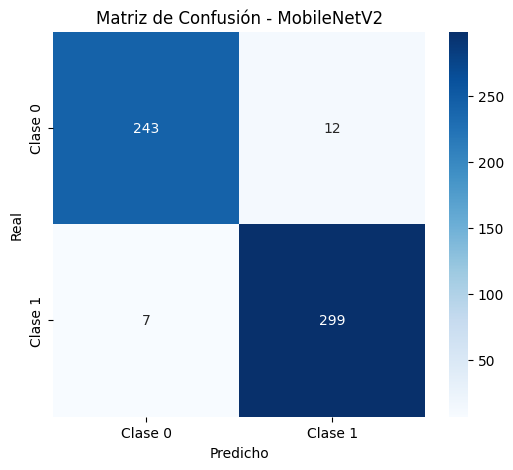


Entrenando modelo: ResNet34
Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 110s 5s/step - accuracy: 0.4515 - loss: 0.7775 - val_accuracy: 0.6791 - val_loss: 0.6557
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 93s 5s/step - accuracy: 0.6159 - loss: 0.6595 - val_accuracy: 0.5740 - val_loss: 0.6870
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 94s 5s/step - accuracy: 0.6452 - loss: 0.6478 - val_accuracy: 0.7629 - val_loss: 0.6018
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 94s 5s/step - accuracy: 0.7476 - loss: 0.5967 - val_accuracy: 0.6578 - val_loss: 0.6036
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 96s 5s/step - accuracy: 0.7020 - loss: 0.5936 - val_accuracy: 0.6649 - val_loss: 0.5826
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 102s 6s/step - accuracy: 0.7309 - loss: 0.5701 - val_accuracy: 0.7201 - val_loss: 0.5413
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 89s 5s/step - accuracy: 0.7648 - loss: 0.5226 - val_accuracy: 0.7629 - val_loss: 0.5069
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 94s 5s/step - accuracy: 0.8097 - loss: 0.4930 - v

Precisión de ResNet34 en el conjunto de prueba: 82.18%

Guardando datos de validación y prueba para ResNet34...

✅ Datos guardados en X_val_ResNet34.npy, y_val_ResNet34.npy, X_test_ResNet34.npy y y_test_ResNet34.npy

Evaluando métricas para ResNet34...

18/18 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step
Matriz de Confusión:
 [[128 127]
 [  3 303]]
Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.98      0.50      0.66       255
           1       0.70      0.99      0.82       306

    accuracy                           0.77       561
   macro avg       0.84      0.75      0.74       561
weighted avg       0.83      0.77      0.75       561

F1-Score: 0.7505708697700137
Precisión: 0.8284911963591176
Error Tipo I (Falsos Positivos): 127
Error Tipo II (Falsos Negativos): 3


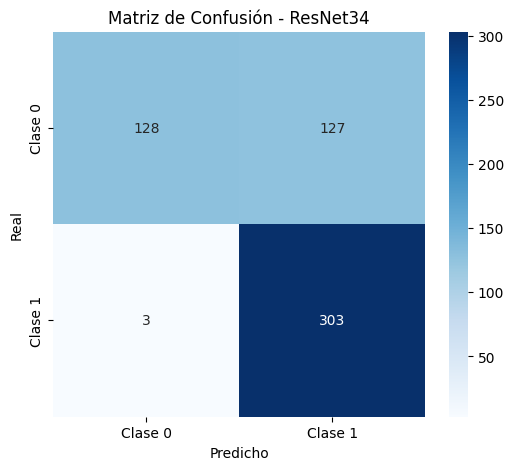


Entrenando modelo: VGG16bn
Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 198s 11s/step - accuracy: 0.6370 - loss: 1.2058 - val_accuracy: 0.8770 - val_loss: 0.2846
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 151s 8s/step - accuracy: 0.9084 - loss: 0.2327 - val_accuracy: 0.9323 - val_loss: 0.1878
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 143s 8s/step - accuracy: 0.8992 - loss: 0.2349 - val_accuracy: 0.9430 - val_loss: 0.1474
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 148s 8s/step - accuracy: 0.9461 - loss: 0.1460 - val_accuracy: 0.9626 - val_loss: 0.1282
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 149s 8s/step - accuracy: 0.9567 - loss: 0.1539 - val_accuracy: 0.9519 - val_loss: 0.1284
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 154s 8s/step - accuracy: 0.9503 - loss: 0.1491 - val_accuracy: 0.9501 - val_loss: 0.1376
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 126s 7s/step - accuracy: 0.9729 - loss: 0.1058 - val_accuracy: 0.9590 - val_loss: 0.1058
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 139s 7s/step - accuracy: 0.9471 - loss: 0.13

Precisión de VGG16bn en el conjunto de prueba: 86.18%

Guardando datos de validación y prueba para VGG16bn...

✅ Datos guardados en X_val_VGG16bn.npy, y_val_VGG16bn.npy, X_test_VGG16bn.npy y y_test_VGG16bn.npy

Evaluando métricas para VGG16bn...

18/18 ━━━━━━━━━━━━━━━━━━━━ 108s 6s/step
Matriz de Confusión:
 [[253   2]
 [ 12 294]]
Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97       255
           1       0.99      0.96      0.98       306

    accuracy                           0.98       561
   macro avg       0.97      0.98      0.97       561
weighted avg       0.98      0.98      0.98       561

F1-Score: 0.9750772483330623
Precisión: 0.9757313059199851
Error Tipo I (Falsos Positivos): 2
Error Tipo II (Falsos Negativos): 12


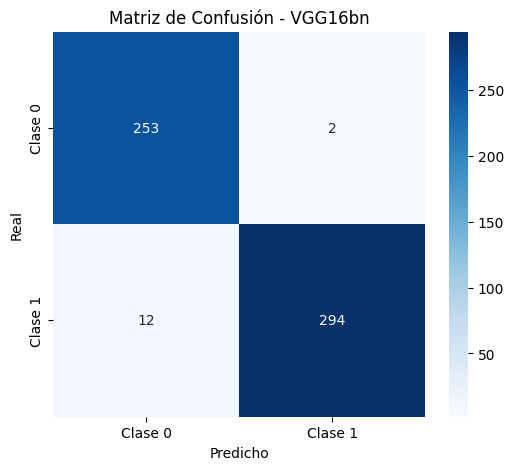

In [17]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2, ResNet50, VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Flatten
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, f1_score, precision_score
import seaborn as sns
import matplotlib.pyplot as plt

# Parámetros
img_size = (224, 224)  
batch_size = 32
epochs = 10
data_dir = r"C:/Users/diana/OneDrive - Universidad de los Andes/Documentos/9no Semestre/TesisGEB_AlejaYCami/Repositorio/ProyectoGradoGEB/modelos"  # 📌 Reemplaza con la ruta real

# Generador de datos con división en entrenamiento (70%), validación (20%) y prueba (10%)
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.3)  # 20% para validación y prueba

test_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.33)  # Divide el 20% en 10% validación y 10% prueba

# Generador de entrenamiento (70% de los datos)
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="training"
)

# Generador de validación (20% de los datos)
val_generator = test_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="training",  # La primera mitad del 20% restante
    shuffle=False
)

# Generador de prueba (10% de los datos)
test_generator = test_datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="validation",  # La otra mitad del 20% restante
    shuffle=False
)

print(f"Total imágenes en entrenamiento: {train_generator.samples}")
print(f"Total imágenes en validación: {val_generator.samples}")
print(f"Total imágenes en prueba: {test_generator.samples}")

# Función para construir modelos
def build_model(base_model):
    base_model.trainable = False  
    
    inputs = base_model.input
    x = base_model.output
    x = GlobalAveragePooling2D()(x) if "mobilenet" in base_model.name.lower() or "resnet" in base_model.name.lower() else Flatten()(x)
    
    x = Dense(128, activation="relu")(x)
    outputs = Dense(1, activation="sigmoid")(x)  
    
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Definir los modelos
models = {
    "MobileNetV2": MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet"),
    "ResNet34": ResNet50(input_shape=(224, 224, 3), include_top=False, weights="imagenet"),  
    "VGG16bn": VGG16(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
}

# Entrenar y evaluar cada modelo
for name, base_model in models.items():
    print(f"\nEntrenando modelo: {name}")
    
    model = build_model(base_model)  

    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=epochs
    )

    # Evaluar en conjunto de prueba (final)
    test_loss, test_acc = model.evaluate(test_generator)
    print(f"Precisión de {name} en el conjunto de prueba: {test_acc * 100:.2f}%")

    # Guardar el modelo
    model.save(f"modelo_anomalias_{name}.h5")  

    # 🚀 Guardar datos de validación y prueba en NumPy
    print(f"\nGuardando datos de validación y prueba para {name}...\n")
    
    X_val = np.concatenate([val_generator[i][0] for i in range(len(val_generator))])
    y_val = np.concatenate([val_generator[i][1] for i in range(len(val_generator))])

    X_test = np.concatenate([test_generator[i][0] for i in range(len(test_generator))])
    y_test = np.concatenate([test_generator[i][1] for i in range(len(test_generator))])

    np.save(f"X_val_{name}.npy", X_val)
    np.save(f"y_val_{name}.npy", y_val)
    np.save(f"X_test_{name}.npy", X_test)
    np.save(f"y_test_{name}.npy", y_test)

    print(f"✅ Datos guardados en X_val_{name}.npy, y_val_{name}.npy, X_test_{name}.npy y y_test_{name}.npy")

    # 🚀 Evaluar métricas con conjunto de prueba
    print(f"\nEvaluando métricas para {name}...\n")

    # Obtener etiquetas reales de validación
    y_val_classes = val_generator.classes  

    # Obtener predicciones del modelo
    y_pred_proba = model.predict(val_generator)  
    y_pred = (y_pred_proba > 0.5).astype(int).flatten()  

    # Matriz de Confusión
    matriz_conf = confusion_matrix(y_val_classes, y_pred)
    print("Matriz de Confusión:\n", matriz_conf)

    # Reporte de clasificación
    print("Reporte de Clasificación:\n", classification_report(y_val_classes, y_pred))

    # Obtener métricas individuales
    f1 = f1_score(y_val_classes, y_pred, average='weighted')
    precision = precision_score(y_val_classes, y_pred, average='weighted')

    print(f"F1-Score: {f1}")
    print(f"Precisión: {precision}")

    # Extraer valores de la matriz de confusión
    TN, FP, FN, TP = matriz_conf.ravel()

    # Error Tipo I (Falsos Positivos)
    error_tipo_1 = FP

    # Error Tipo II (Falsos Negativos)
    error_tipo_2 = FN

    print(f"Error Tipo I (Falsos Positivos): {error_tipo_1}")
    print(f"Error Tipo II (Falsos Negativos): {error_tipo_2}")

    # 📊 Visualizar la Matriz de Confusión
    plt.figure(figsize=(6, 5))
    sns.heatmap(matriz_conf, annot=True, fmt="d", cmap="Blues", xticklabels=["Clase 0", "Clase 1"], yticklabels=["Clase 0", "Clase 1"])
    plt.xlabel("Predicho")
    plt.ylabel("Real")
    plt.title(f"Matriz de Confusión - {name}")
    plt.show()


📂 normal: 456 imágenes encontradas
📂 anomalo: 380 imágenes encontradas

✅ Total de imágenes cargadas: 836
Clases: 0 = 456, 1 = 380

📊 División de datos:
Entrenamiento: 585
Validación: 168
Prueba: 83

🚀 Entrenando modelo: MobileNetV2
Epoch 1/10
19/19 [==============================] - 28s 905ms/step - loss: 0.3554 - accuracy: 0.8427 - val_loss: 0.2794 - val_accuracy: 0.8690
Epoch 2/10
19/19 [==============================] - 14s 754ms/step - loss: 0.2573 - accuracy: 0.8769 - val_loss: 0.2157 - val_accuracy: 0.9107
Epoch 3/10
19/19 [==============================] - 12s 660ms/step - loss: 0.1978 - accuracy: 0.9162 - val_loss: 0.2078 - val_accuracy: 0.9167
Epoch 4/10
19/19 [==============================] - 11s 575ms/step - loss: 0.1774 - accuracy: 0.9333 - val_loss: 0.2201 - val_accuracy: 0.9107
Epoch 5/10
19/19 [==============================] - 14s 765ms/step - loss: 0.1715 - accuracy: 0.9265 - val_loss: 0.1988 - val_accuracy: 0.9107
Epoch 6/10
19/19 [==============================] - 

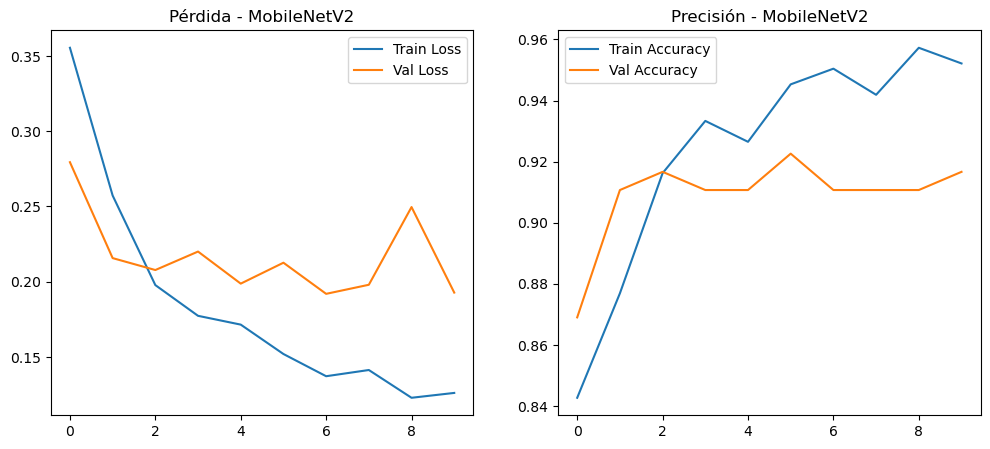


📊 Resultados para Train - MobileNetV2
19/19 [==============================] - 13s 568ms/step
🧾 Matriz de Confusión:
 [[311   8]
 [ 13 253]]
📝 Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.96      0.97      0.97       319
           1       0.97      0.95      0.96       266

    accuracy                           0.96       585
   macro avg       0.96      0.96      0.96       585
weighted avg       0.96      0.96      0.96       585

📌 F1-Score: 0.96
📌 Precisión: 0.96
⚠️ Error Tipo I (Falsos Positivos): 8
⚠️ Error Tipo II (Falsos Negativos): 13


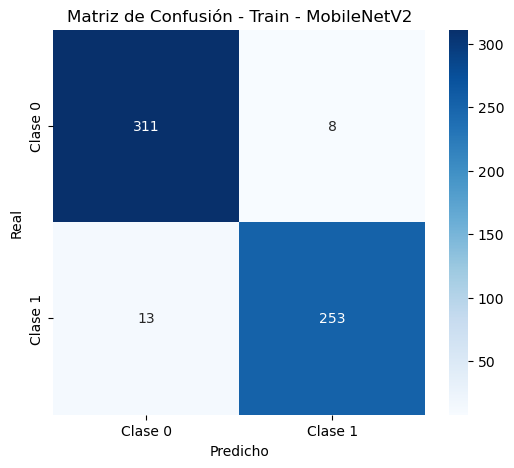


📊 Resultados para Val - MobileNetV2
6/6 [==============================] - 3s 552ms/step
🧾 Matriz de Confusión:
 [[87  5]
 [ 9 67]]
📝 Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.91      0.95      0.93        92
           1       0.93      0.88      0.91        76

    accuracy                           0.92       168
   macro avg       0.92      0.91      0.92       168
weighted avg       0.92      0.92      0.92       168

📌 F1-Score: 0.92
📌 Precisión: 0.92
⚠️ Error Tipo I (Falsos Positivos): 5
⚠️ Error Tipo II (Falsos Negativos): 9


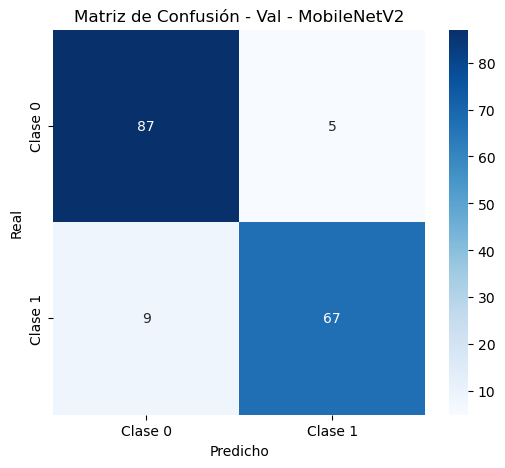


📊 Resultados para Test - MobileNetV2
3/3 [==============================] - 2s 530ms/step
🧾 Matriz de Confusión:
 [[41  4]
 [ 3 35]]
📝 Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.93      0.91      0.92        45
           1       0.90      0.92      0.91        38

    accuracy                           0.92        83
   macro avg       0.91      0.92      0.92        83
weighted avg       0.92      0.92      0.92        83

📌 F1-Score: 0.92
📌 Precisión: 0.92
⚠️ Error Tipo I (Falsos Positivos): 4
⚠️ Error Tipo II (Falsos Negativos): 3


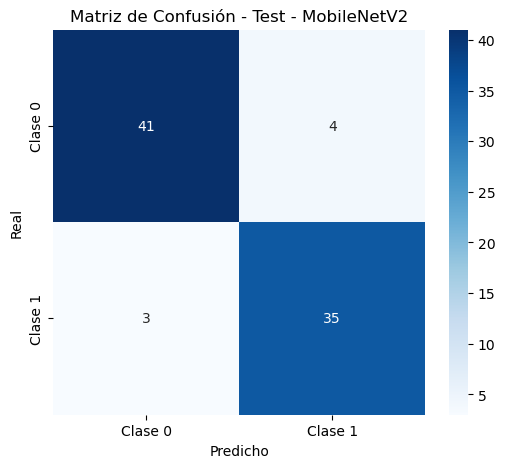

3/3 [==============================] - 2s 642ms/step - loss: 0.2197 - accuracy: 0.9157

🎯 Precisión en prueba para MobileNetV2: 91.57%

🚀 Entrenando modelo: ResNet50
Epoch 1/10
19/19 [==============================] - 47s 2s/step - loss: 0.7148 - accuracy: 0.5333 - val_loss: 0.7044 - val_accuracy: 0.4524
Epoch 2/10
19/19 [==============================] - 39s 2s/step - loss: 0.6212 - accuracy: 0.6581 - val_loss: 0.6006 - val_accuracy: 0.7440
Epoch 3/10
19/19 [==============================] - 44s 2s/step - loss: 0.5806 - accuracy: 0.7333 - val_loss: 0.5983 - val_accuracy: 0.6607
Epoch 4/10
19/19 [==============================] - 39s 2s/step - loss: 0.5879 - accuracy: 0.6803 - val_loss: 0.5530 - val_accuracy: 0.7381
Epoch 5/10
19/19 [==============================] - 41s 2s/step - loss: 0.5200 - accuracy: 0.7744 - val_loss: 0.6025 - val_accuracy: 0.6726
Epoch 6/10
19/19 [==============================] - 38s 2s/step - loss: 0.5063 - accuracy: 0.7795 - val_loss: 0.5076 - val_accuracy: 0

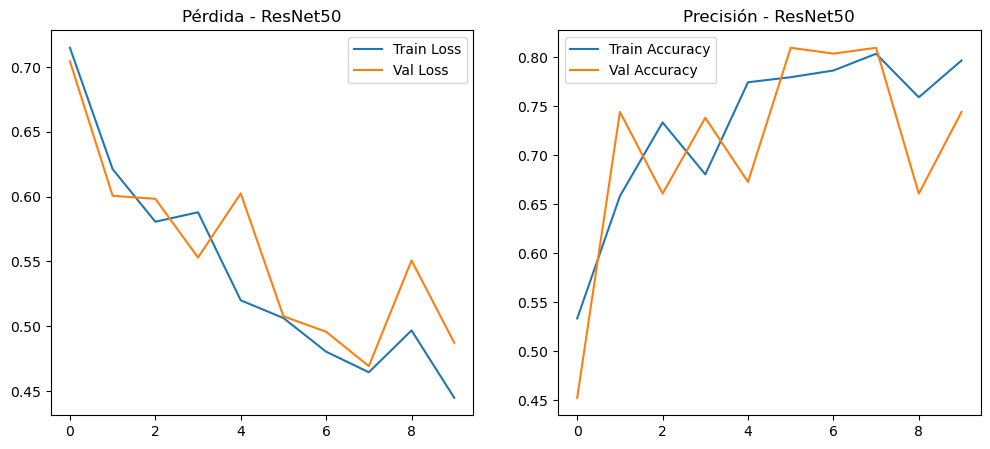


📊 Resultados para Train - ResNet50
19/19 [==============================] - 42s 2s/step
🧾 Matriz de Confusión:
 [[318   1]
 [133 133]]
📝 Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.71      1.00      0.83       319
           1       0.99      0.50      0.67       266

    accuracy                           0.77       585
   macro avg       0.85      0.75      0.75       585
weighted avg       0.84      0.77      0.75       585

📌 F1-Score: 0.75
📌 Precisión: 0.84
⚠️ Error Tipo I (Falsos Positivos): 1
⚠️ Error Tipo II (Falsos Negativos): 133


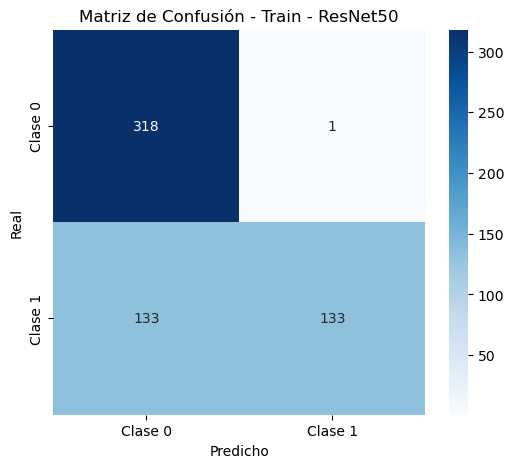


📊 Resultados para Val - ResNet50
6/6 [==============================] - 10s 2s/step
🧾 Matriz de Confusión:
 [[92  0]
 [43 33]]
📝 Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.68      1.00      0.81        92
           1       1.00      0.43      0.61        76

    accuracy                           0.74       168
   macro avg       0.84      0.72      0.71       168
weighted avg       0.83      0.74      0.72       168

📌 F1-Score: 0.72
📌 Precisión: 0.83
⚠️ Error Tipo I (Falsos Positivos): 0
⚠️ Error Tipo II (Falsos Negativos): 43


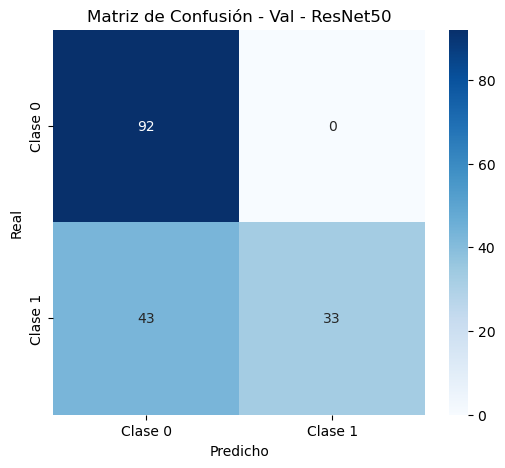


📊 Resultados para Test - ResNet50
3/3 [==============================] - 6s 2s/step
🧾 Matriz de Confusión:
 [[45  0]
 [23 15]]
📝 Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.66      1.00      0.80        45
           1       1.00      0.39      0.57        38

    accuracy                           0.72        83
   macro avg       0.83      0.70      0.68        83
weighted avg       0.82      0.72      0.69        83

📌 F1-Score: 0.69
📌 Precisión: 0.82
⚠️ Error Tipo I (Falsos Positivos): 0
⚠️ Error Tipo II (Falsos Negativos): 23


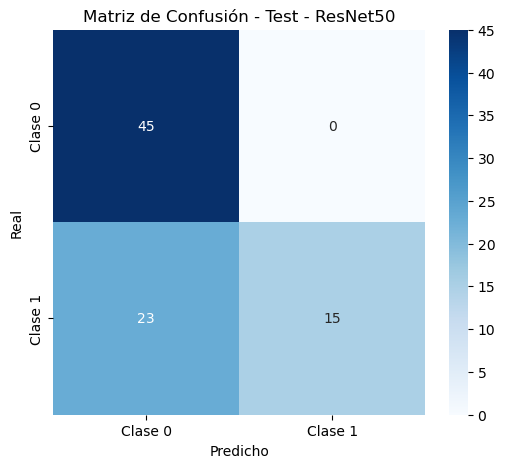

3/3 [==============================] - 6s 2s/step - loss: 0.5203 - accuracy: 0.7229

🎯 Precisión en prueba para ResNet50: 72.29%

🚀 Entrenando modelo: VGG16
Epoch 1/10
19/19 [==============================] - 111s 6s/step - loss: 1.6066 - accuracy: 0.5333 - val_loss: 0.6484 - val_accuracy: 0.7560
Epoch 2/10
19/19 [==============================] - 89s 5s/step - loss: 0.6088 - accuracy: 0.6974 - val_loss: 0.5766 - val_accuracy: 0.8036
Epoch 3/10
19/19 [==============================] - 92s 5s/step - loss: 0.5444 - accuracy: 0.7761 - val_loss: 0.5300 - val_accuracy: 0.7143
Epoch 4/10
19/19 [==============================] - 91s 5s/step - loss: 0.5074 - accuracy: 0.8376 - val_loss: 0.5052 - val_accuracy: 0.7798
Epoch 5/10
19/19 [==============================] - 91s 5s/step - loss: 0.4907 - accuracy: 0.8547 - val_loss: 0.4866 - val_accuracy: 0.8274
Epoch 6/10
19/19 [==============================] - 91s 5s/step - loss: 0.4740 - accuracy: 0.8803 - val_loss: 0.4752 - val_accuracy: 0.9226
Ep

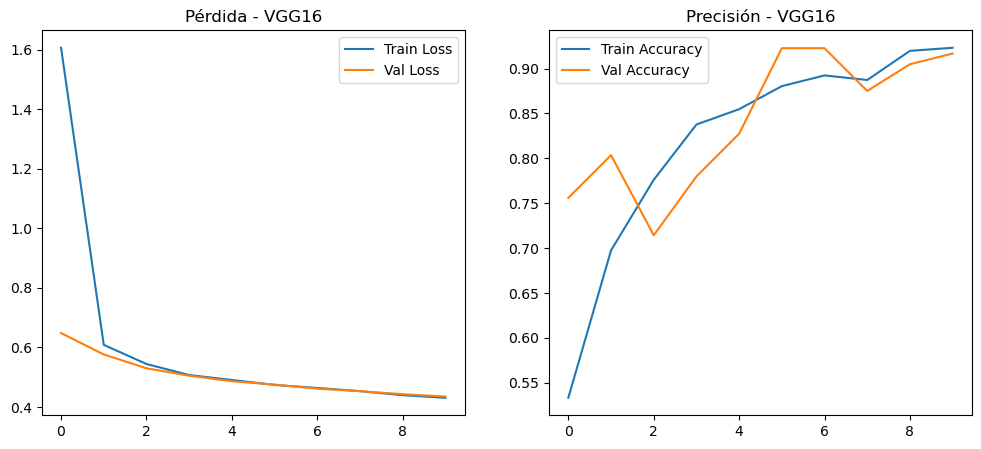


📊 Resultados para Train - VGG16
19/19 [==============================] - 79s 4s/step
🧾 Matriz de Confusión:
 [[286  33]
 [  9 257]]
📝 Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.97      0.90      0.93       319
           1       0.89      0.97      0.92       266

    accuracy                           0.93       585
   macro avg       0.93      0.93      0.93       585
weighted avg       0.93      0.93      0.93       585

📌 F1-Score: 0.93
📌 Precisión: 0.93
⚠️ Error Tipo I (Falsos Positivos): 33
⚠️ Error Tipo II (Falsos Negativos): 9


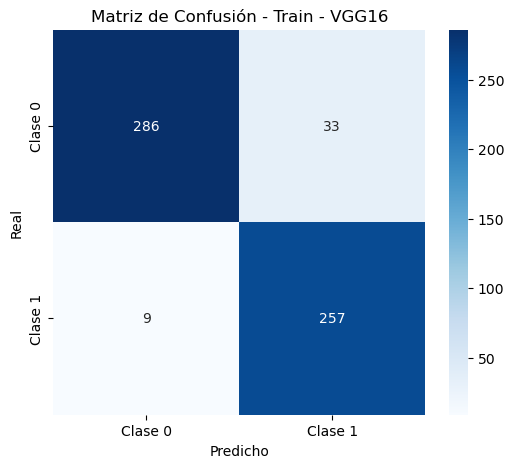


📊 Resultados para Val - VGG16
6/6 [==============================] - 23s 3s/step
🧾 Matriz de Confusión:
 [[80 12]
 [ 2 74]]
📝 Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.98      0.87      0.92        92
           1       0.86      0.97      0.91        76

    accuracy                           0.92       168
   macro avg       0.92      0.92      0.92       168
weighted avg       0.92      0.92      0.92       168

📌 F1-Score: 0.92
📌 Precisión: 0.92
⚠️ Error Tipo I (Falsos Positivos): 12
⚠️ Error Tipo II (Falsos Negativos): 2


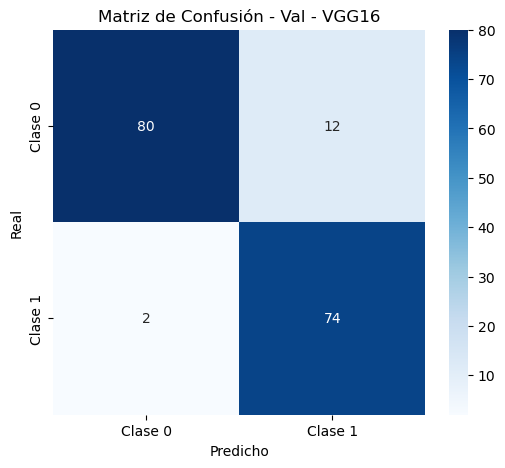


📊 Resultados para Test - VGG16
3/3 [==============================] - 11s 3s/step
🧾 Matriz de Confusión:
 [[33 12]
 [ 2 36]]
📝 Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.94      0.73      0.82        45
           1       0.75      0.95      0.84        38

    accuracy                           0.83        83
   macro avg       0.85      0.84      0.83        83
weighted avg       0.85      0.83      0.83        83

📌 F1-Score: 0.83
📌 Precisión: 0.85
⚠️ Error Tipo I (Falsos Positivos): 12
⚠️ Error Tipo II (Falsos Negativos): 2


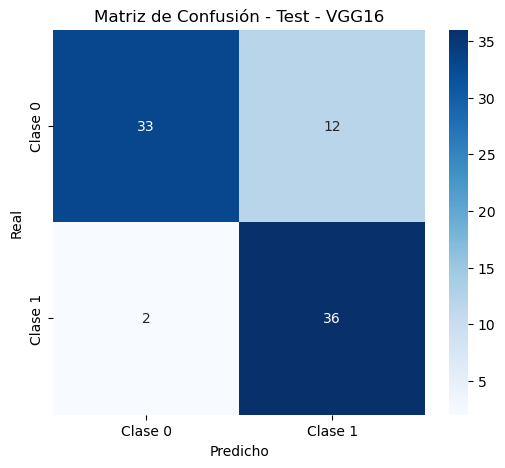

3/3 [==============================] - 11s 3s/step - loss: 0.4585 - accuracy: 0.8313

🎯 Precisión en prueba para VGG16: 83.13%


In [11]:
import os
import numpy as np
import tensorflow as tf
import cv2
from tensorflow.keras.applications import MobileNetV2, ResNet50, VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Flatten
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score, precision_score
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# === PARÁMETROS ===
img_size = (224, 224)
batch_size = 32
epochs = 10
data_dir = r"C:\Users\jupap\OneDrive - Universidad de los andes\Tesis Camiii\ProyectoGradoGEB\modelos"
extensiones_validas = [".jpg", ".jpeg", ".png"]

# === CARGA MANUAL DE IMÁGENES ===
X, y = [], []

for label_dir in ["normal", "anomalo"]:
    folder_path = os.path.join(data_dir, label_dir)
    label = 0 if label_dir == "normal" else 1

    if not os.path.exists(folder_path):
        print(f"⚠️ Carpeta no encontrada: {folder_path}")
        continue

    imagenes = [f for f in os.listdir(folder_path) if any(f.lower().endswith(ext) for ext in extensiones_validas)]

    print(f"📂 {label_dir}: {len(imagenes)} imágenes encontradas")

    for fname in imagenes:
        # Reemplaza dentro del loop de carga:
        try:
            img_path = os.path.join(folder_path, fname)
            img = Image.open(img_path).convert("RGB")
            img = img.resize(img_size)
            img = np.array(img) / 255.0
            X.append(img)
            y.append(label)
        except Exception as e:
            print(f"❌ Error cargando {img_path}: {e}")

X = np.array(X)
y = np.array(y)

print(f"\n✅ Total de imágenes cargadas: {len(X)}")
print(f"Clases: 0 = {np.sum(np.array(y) == 0)}, 1 = {np.sum(np.array(y) == 1)}")

if len(X) == 0:
    raise ValueError("No se cargaron imágenes. Verifica la ruta y extensiones.")

# === SPLIT ===
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.33, stratify=y_temp, random_state=42)

print(f"\n📊 División de datos:")
print(f"Entrenamiento: {len(X_train)}")
print(f"Validación: {len(X_val)}")
print(f"Prueba: {len(X_test)}")

# === FUNCIÓN PARA CONSTRUIR MODELOS ===
def build_model(base_model):
    base_model.trainable = False
    x = GlobalAveragePooling2D()(base_model.output) if "mobilenet" in base_model.name.lower() or "resnet" in base_model.name.lower() else Flatten()(base_model.output)
    x = Dense(128, activation="relu")(x)
    output = Dense(1, activation="sigmoid")(x)
    return Model(inputs=base_model.input, outputs=output)

# === DEFINIR MODELOS BASE ===
models = {
    "MobileNetV2": MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet"),
    "ResNet50": ResNet50(input_shape=(224, 224, 3), include_top=False, weights="imagenet"),
    "VGG16": VGG16(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
}

# === ENTRENAMIENTO Y EVALUACIÓN ===
for name, base_model in models.items():
    print(f"\n🚀 Entrenando modelo: {name}")
    model = build_model(base_model)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size
    )

    # === GUARDAR MODELO Y DATOS ===
    model.save(f"modelo_CNN_Semanal_{name}.h5")
  
    # === GRÁFICA DE PÉRDIDA Y PRECISIÓN ===
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.title(f"Pérdida - {name}")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Val Accuracy")
    plt.title(f"Precisión - {name}")
    plt.legend()
    plt.show()

    # === MÉTRICAS PARA TRAIN Y VAL ===
    for set_name, X_set, y_true in zip(
        ["Train", "Val"],
        [X_train, X_val],
        [y_train, y_val]
    ):
        print(f"\n📊 Resultados para {set_name} - {name}")
        y_pred_proba = model.predict(X_set)
        y_pred = (y_pred_proba > 0.5).astype(int).flatten()

        matriz_conf = confusion_matrix(y_true, y_pred)
        print("🧾 Matriz de Confusión:\n", matriz_conf)
        print("📝 Reporte de Clasificación:\n", classification_report(y_true, y_pred))

        f1 = f1_score(y_true, y_pred, average='weighted')
        precision = precision_score(y_true, y_pred, average='weighted')
        print(f"📌 F1-Score: {f1:.2f}")
        print(f"📌 Precisión: {precision:.2f}")

        TN, FP, FN, TP = matriz_conf.ravel()
        print(f"⚠️ Error Tipo I (Falsos Positivos): {FP}")
        print(f"⚠️ Error Tipo II (Falsos Negativos): {FN}")

        plt.figure(figsize=(6, 5))
        sns.heatmap(matriz_conf, annot=True, fmt="d", cmap="Blues", xticklabels=["Clase 0", "Clase 1"], yticklabels=["Clase 0", "Clase 1"])
        plt.xlabel("Predicho")
        plt.ylabel("Real")
        plt.title(f"Matriz de Confusión - {set_name} - {name}")
        plt.show()

        # === MÉTRICAS COMPLETAS PARA TEST ===
    print(f"\n📊 Resultados para Test - {name}")
    y_pred_proba = model.predict(X_test)
    y_pred = (y_pred_proba > 0.5).astype(int).flatten()

    matriz_conf = confusion_matrix(y_test, y_pred)
    print("🧾 Matriz de Confusión:\n", matriz_conf)
    print("📝 Reporte de Clasificación:\n", classification_report(y_test, y_pred))

    f1 = f1_score(y_test, y_pred, average='weighted')
    precision = precision_score(y_test, y_pred, average='weighted')
    print(f"📌 F1-Score: {f1:.2f}")
    print(f"📌 Precisión: {precision:.2f}")

    TN, FP, FN, TP = matriz_conf.ravel()
    print(f"⚠️ Error Tipo I (Falsos Positivos): {FP}")
    print(f"⚠️ Error Tipo II (Falsos Negativos): {FN}")

    plt.figure(figsize=(6, 5))
    sns.heatmap(matriz_conf, annot=True, fmt="d", cmap="Blues", xticklabels=["Clase 0", "Clase 1"], yticklabels=["Clase 0", "Clase 1"])
    plt.xlabel("Predicho")
    plt.ylabel("Real")
    plt.title(f"Matriz de Confusión - Test - {name}")
    plt.show()


    # === EVALUACIÓN FINAL EN PRUEBA ===
    test_loss, test_acc = model.evaluate(X_test, y_test)
    print(f"\n🎯 Precisión en prueba para {name}: {test_acc * 100:.2f}%")
